# Part 2 - Other features analysis

## ..

### Installation

In [ ]:
#pip install statsmodels

In [1]:
#pip install torch

In [2]:
#pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#pip install requests

In [2]:
#pip install matplotlib

In [4]:
#pip install scikit-learn

In [5]:
#pip install keras

Note: you may need to restart the kernel to use updated packages.


### Importing packages

In [1]:
# Import packages
import json
import csv
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### OTHER

#### *100m sprint*

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# URL of the page to scrape
url = "https://worldathletics.org/records/all-time-toplists/sprints/100-metres/outdoor/men/senior"

# Send a request to fetch the page content
response = requests.get(url)
response.raise_for_status()  # Ensure the request was successful

# Parse the page content
soup = BeautifulSoup(response.text, 'html.parser')

# Find the table containing the data
table = soup.find('table')

# Extract table headers
headers = [header.text.strip() for header in table.find_all('th')]

# Extract table rows
rows = []
for row in table.find_all('tr')[1:]:  # Skip the header row
    columns = row.find_all('td')
    row_data = [col.text.strip() for col in columns]
    rows.append(row_data)

# Create a DataFrame
df = pd.DataFrame(rows, columns=headers)

# Save the data to a CSV file
df.to_csv('100m_sprint_all_time_toplist.csv', index=False)

print("Data has been saved to 100m_sprint_all_time_toplist.csv")


Data has been saved to 100m_sprint_all_time_toplist.csv


In [2]:
df

,Rank,Mark,WIND,Competitor,DOB,Nat,Pos,,Venue,Date,Results Score
0,1,9.58,+0.9,Usain BOLT,21 AUG 1986,JAM,1,,"Olympiastadion, Berlin (GER)",16 AUG 2009,1356
1,2,9.69,+2.0,Tyson GAY,09 AUG 1982,USA,1,,Shanghai (CHN),20 SEP 2009,1316
2,2,9.69,-0.1,Yohan BLAKE,26 DEC 1989,JAM,1,,"Stade Olympique de la Pontaise, Lausanne (SUI)",23 AUG 2012,1316
3,4,9.72,+0.2,Asafa POWELL,23 NOV 1982,JAM,1f1,,"Stade Olympique de la Pontaise, Lausanne (SUI)",02 SEP 2008,1305
4,5,9.74,+0.9,Justin GATLIN,10 FEB 1982,USA,1,,"Suhaim bin Hamad Stadium, Doha (QAT)",15 MAY 2015,1298
...,...,...,...,...,...,...,...,...,...,...,...
95,95,9.94,-0.2,Bernard WILLIAMS,19 JAN 1978,USA,2,,"Commonwealth Stadium, Edmonton (CAN)",05 AUG 2001,1228
96,95,9.94,+1.7,Diondre BATSON,13 JUL 1992,USA,2h2,,"Hayward Field, Eugene, OR (USA)",25 JUN 2015,1227
97,95,9.94,+1.4,Andrew FISHER,15 DEC 1991,JAM,2,,"Moratalaz, Madrid (ESP)",11 JUL 2015,1227
98,95,9.94,+1.0,Ameer WEBB,19 MAR 1991,USA,2f1,,"Stadio Olimpico, Roma (ITA)",02 JUN 2016,1227


We now have created a dataframe and saved it in a csv file. This gives us informations about the 100 first athletes for the 100m sprint in the world.

We have 11 columns:
- ID
- Rank
- Mark
- WIND
- Competitor (the name and surname of the athlete)
- DOB (the date of birth)
- NAT (nationality)
- Pos (I don't know yet)
- Venue (The venue in which he made his best time)
- Date (the date he made his best time)
- Result score

We ideally want to have more information about each individual athlete. To do that, another page of this website has access to their profile page. We need to get access to it doing once again webscrapping.

## Data collection

Web scrapping with *beautifulsoup4* from the website https://worldathletics.org/world-rankings/5000m/men?regionType=world&page=1&rankDate=2024-06-04&limitByCountry=0

#### *5000m*

In [2]:
#pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


Import packages

Create and define functions

In [2]:
# Function to fetch athlete profile URLs and nationalities
def fetch_profile_urls():
    url = "https://worldathletics.org/world-rankings/5000m/men?regionType=world&page=1&rankDate=2024-06-04&limitByCountry=0"
    response = requests.get(url)
    response.raise_for_status()  # Ensure the request was successful

    soup = BeautifulSoup(response.text, 'html.parser')

    # Find all table rows containing athlete data
    athlete_rows = soup.find_all('tr', class_='table-row--hover')

    athletes = {}
    for row in athlete_rows:
        name_element = row.find('td', {'data-th': 'Competitor'})
        if name_element:
            name = name_element.text.strip()
            profile_url = "https://worldathletics.org" + row['data-athlete-url']
            nationality_element = row.find('td', {'data-th': 'Nat'})
            if nationality_element:
                nationality = nationality_element.text.strip()
            else:
                nationality = ""
            athletes[name] = {'profile_url': profile_url, 'nationality': nationality}

    return athletes

In [3]:
# Function to recursively search for 5000 meters results
def search_5000m_results(node, results):
    if isinstance(node, dict):
        for key, value in node.items():
            if isinstance(value, list) or isinstance(value, dict):
                search_5000m_results(value, results)
            elif key == 'discipline' and '5000 Metres' in value:
                results.append(node)
    elif isinstance(node, list):
        for item in node:
            if isinstance(item, list) or isinstance(item, dict):
                search_5000m_results(item, results)


# Function to extract 5000m results for a given athlete URL
def extract_5000m_results(url):
    # Fetch the HTML content of the page
    response = requests.get(url)
    response.raise_for_status()  # Ensure the request was successful
    html_content = response.text

    # Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(html_content, 'html.parser')

    # Find the <script> tag with id="__NEXT_DATA__" and type="application/json"
    script_tag = soup.find('script', {'id': '__NEXT_DATA__', 'type': 'application/json'})

    # Extract the JSON content from the <script> tag
    json_content = script_tag.string

    # Parse the JSON content
    data = json.loads(json_content)

    # Extract 5000 meters results
    results_5000m = []
    search_5000m_results(data, results_5000m)

    return results_5000m


In [4]:
# Function to extract relevant data
def extract_5000m_data(athlete, nationality, results):
    for result in results:
        # Check if this is a progression result with multiple results
        if 'results' in result:
            for progression in result['results']:
                rows.append({
                    'Athlete': athlete,
                    'Nationality': nationality,
                    'Score': progression.get('resultScore', ''),
                    'Date': progression.get('date', ''),
                    'Venue': progression.get('venue', ''),
                    'Place': progression.get('place', '')  # Use 'listPosition' instead of 'place'
                })
        else:
            rows.append({
                'Athlete': athlete,
                'Nationality': nationality,
                'Score': result.get('resultScore', ''),
                'Date': result.get('date', ''),
                'Venue': result.get('venue', ''),
                'Place': result.get('place', '')  # Use 'listPosition' instead of 'place'
            })

Create a dataset in a data frame and csv format.

In [8]:
import os
import csv

# Ensure the directory exists
os.makedirs('data', exist_ok=True)

# Fetch athlete profile URLs
athletes = fetch_profile_urls()

# List to hold all extracted rows
all_rows = []

# Loop through each athlete and extract their 5000m results
for athlete, data in athletes.items():
    athlete_url = data['profile_url']
    nationality = data['nationality']
    #print(f"Extracting 5000m results for {athlete}...")
    athlete_results = extract_5000m_results(athlete_url)
    
    # List to hold the extracted rows for this athlete
    rows = []
    # Extract data for this athlete
    extract_5000m_data(athlete, nationality, athlete_results)
    # Add rows for this athlete to the list of all rows
    all_rows.extend(rows)

# Define CSV file name
csv_file_name = 'data/5000m_results_with_urls.csv'

# Write all rows to CSV
with open(csv_file_name, 'w', newline='') as csv_file:
    fieldnames = ['Athlete', 'Nationality', 'Score', 'Date', 'Venue', 'Place']  # Add 'Athlete' field
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    for row in all_rows:
        writer.writerow(row)

print(f"Data successfully written to {csv_file_name}")


Data successfully written to data/5000m_results_with_urls.csv


## Preprocessing the data

### Put the right type of attribute to each variable, drop NA values 

In [2]:
df_5000m = pd.read_csv("data/5000m_results_with_urls.csv")
print(df_5000m.head())
print(df_5000m.info())

          Athlete Nationality   Score         Date  \
0  Yomif KEJELCHA         ETH  1288.0  30 MAY 2024   
1  Yomif KEJELCHA         ETH  1288.0  30 MAY 2024   
2  Yomif KEJELCHA         ETH  1119.0  25 JUL 2014   
3  Yomif KEJELCHA         ETH  1232.0  11 SEP 2015   
4  Yomif KEJELCHA         ETH  1198.0  14 MAY 2016   

                               Venue  Place  
0        Bislett Stadion, Oslo (NOR)    NaN  
1        Bislett Stadion, Oslo (NOR)    NaN  
2    Hayward Field, Eugene, OR (USA)    NaN  
3  Boudewijnstadion, Bruxelles (BEL)    NaN  
4   Shanghai Stadium, Shanghai (CHN)    NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete      4152 non-null   object 
 1   Nationality  4152 non-null   object 
 2   Score        1720 non-null   float64
 3   Date         2974 non-null   object 
 4   Venue        2974 non-null   object 

In [3]:
# Counting null values per column
null_counts = df_5000m.isnull().sum()
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
Athlete           0
Nationality       0
Score          2432
Date           1178
Venue          1178
Place          2597
dtype: int64


In [4]:
# Removing rows with null 'Venue' & removing duplicates
df_5000m_cleaned0 = df_5000m.dropna(subset=['Venue', 'Score'])
df_5000m_cleaned1 = df_5000m_cleaned0.drop_duplicates()
df_5000m_cleaned2 = df_5000m_cleaned1.dropna(subset=['Place', 'Score'], how='all')

In [5]:
null_counts = df_5000m_cleaned2.isnull().sum()
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
Athlete          0
Nationality      0
Score            0
Date             0
Venue            0
Place          804
dtype: int64


Now that we have removed all of the rows with NA venue, and all of the rows where either `place`, `score` or both were empty, we need to assign the right type for each variable.

The 5 differents variables are: 
- Athlete: object into character or factor
- Score: float
- Data: object to convert into datetime
- Venue: object into character or factor or to dertermine
- Place: float to convert into nummerical

In [6]:
df = df_5000m_cleaned2
df.loc[:, 'Athlete'] = pd.Categorical(df['Athlete'])
df.loc[:, 'Nationality'] = pd.Categorical(df['Nationality'])
df['Date'] = pd.to_datetime(df['Date'], format='%d %b %Y', errors='coerce')
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print(df.head())
print(df.info())

          Athlete Nationality   Score       Date  \
0  Yomif KEJELCHA         ETH  1288.0 2024-05-30   
2  Yomif KEJELCHA         ETH  1119.0 2014-07-25   
3  Yomif KEJELCHA         ETH  1232.0 2015-09-11   
4  Yomif KEJELCHA         ETH  1198.0 2016-05-14   
5  Yomif KEJELCHA         ETH  1205.0 2017-05-27   

                               Venue  Place  Day  Month  Year  
0        Bislett Stadion, Oslo (NOR)    NaN   30      5  2024  
2    Hayward Field, Eugene, OR (USA)    NaN   25      7  2014  
3  Boudewijnstadion, Bruxelles (BEL)    NaN   11      9  2015  
4   Shanghai Stadium, Shanghai (CHN)    NaN   14      5  2016  
5    Hayward Field, Eugene, OR (USA)    NaN   27      5  2017  
<class 'pandas.core.frame.DataFrame'>
Index: 1127 entries, 0 to 4136
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Athlete      1127 non-null   object        
 1   Nationality  1127 non-null   object        
 2   S

### Data simulation

While reading articles on the sport's prediction, we wanted to ackknowledge the fact that we have to take into account several other parameters than past perfromances. We chose sujbectively to implement the effect of crow cheering on athletes as well as the environmental change. 
- `CrowdCheeringEffect`: the biggest number means = the biggest advantage.
- `EnvironmentalAdaptation`: the biggest number = the biggest advantage.

For example, a French athlete woould have a bigger CrowdCheeringEffect score than a Australian because these Olympic Games are located in France this year. 
Another example would be that an American would have a bigger EnvironmentalAdaptation Score than an African athlete, for example Ethiopian, as the cultural difference is way more pronouced between Ethiopia and France than USA and France.

In [7]:
# Define factors for distance from France, climate similarity, and cultural/travel ease for each country
### WE COULD AUTOMATE THIS
distance_factor = {
    'ETH': 0.5, 'USA': 0.7, 'AUS': 0.9, 'NOR': 0.2, 'GER': 0.1, 'FRA': 0.0, 
    'KEN': 0.5, 'ESP': 0.1, 'GBR': 0.1, 'CAN': 0.6, 'UGA': 0.5, 'SUI': 0.1, 
    'BEL': 0.1, 'JPN': 0.8, 'NED': 0.1, 'IRL': 0.2, 'SWE': 0.2, 'BRN': 0.7, 
    'ITA': 0.1, 'RUS': 0.4, 'GUA': 0.8, 'BDI': 0.5, 'SRB': 0.3, 'RSA': 0.6, 
    'THA': 0.8, 'ERI': 0.5, 'AUT': 0.1, 'DJI': 0.6, 'IND': 0.7, 'URU': 0.8, 'MAR': 0.2
}

climate_factor = {
    'ETH': 0.4, 'USA': 0.6, 'AUS': 0.6, 'NOR': 0.7, 'GER': 0.9, 'FRA': 1.0, 
    'KEN': 0.4, 'ESP': 0.8, 'GBR': 0.8, 'CAN': 0.6, 'UGA': 0.4, 'SUI': 0.9, 
    'BEL': 0.8, 'JPN': 0.6, 'NED': 0.8, 'IRL': 0.8, 'SWE': 0.7, 'BRN': 0.4, 
    'ITA': 0.9, 'RUS': 0.6, 'GUA': 0.3, 'BDI': 0.4, 'SRB': 0.7, 'RSA': 0.5, 
    'THA': 0.3, 'ERI': 0.4, 'AUT': 0.9, 'DJI': 0.4, 'IND': 0.4, 'URU': 0.4, 'MAR': 0.8
}

cultural_factor = {
    'ETH': 0.4, 'USA': 0.7, 'AUS': 0.6, 'NOR': 0.8, 'GER': 0.9, 'FRA': 1.0, 
    'KEN': 0.4, 'ESP': 0.9, 'GBR': 0.9, 'CAN': 0.7, 'UGA': 0.4, 'SUI': 0.9, 
    'BEL': 0.9, 'JPN': 0.6, 'NED': 0.9, 'IRL': 0.8, 'SWE': 0.8, 'BRN': 0.4, 
    'ITA': 0.9, 'RUS': 0.6, 'GUA': 0.3, 'BDI': 0.4, 'SRB': 0.7, 'RSA': 0.4, 
    'THA': 0.3, 'ERI': 0.4, 'AUT': 0.9, 'DJI': 0.3, 'IND': 0.3, 'URU': 0.3, 'MAR': 0.8
}

# Define initial count of athletes per nationality
initial_nationalities = {
    'ETH': 0, 'USA': 0, 'AUS': 0, 'NOR': 0, 'GER': 0, 'FRA': 0, 
    'KEN': 0, 'ESP': 0, 'GBR': 0, 'CAN': 0, 'UGA': 0, 'SUI': 0, 
    'BEL': 0, 'JPN': 0, 'NED': 0, 'IRL': 0, 'SWE': 0, 'BRN': 0, 
    'ITA': 0, 'RUS': 0, 'GUA': 0, 'BDI': 0, 'SRB': 0, 'RSA': 0, 
    'THA': 0, 'ERI': 0, 'AUT': 0, 'DJI': 0, 'IND': 0, 'URU': 0, 'MAR': 0
}

In [8]:
# Define the number of simulations
num_simulations = 10000

# Count the number of athletes per nationality
nationalities = df['Nationality'].value_counts().to_dict()

# Function to calculate mean and standard deviation based on factors
def calculate_params(distance, climate, cultural):
    base_mean = 0.10
    base_std = 0.05
    mean_cheering_effect = base_mean + 0.05 * (1 - distance) + 0.05 * cultural
    std_cheering_effect = base_std - 0.01 * cultural
    
    mean_environmental_adaptation = base_mean + 0.05 * climate
    std_environmental_adaptation = base_std - 0.01 * climate
    
    return mean_cheering_effect, std_cheering_effect, mean_environmental_adaptation, std_environmental_adaptation

# Create the params dictionary
params = {}
for nationality in nationalities.keys():
    mean_cheering_effect, std_cheering_effect, mean_environmental_adaptation, std_environmental_adaptation = calculate_params(
        distance_factor.get(nationality, 0), climate_factor.get(nationality, 0), cultural_factor.get(nationality, 0)
    )
    params[nationality] = {
        'mean_cheering_effect': mean_cheering_effect, 'std_cheering_effect': std_cheering_effect,
        'mean_environmental_adaptation': mean_environmental_adaptation, 'std_environmental_adaptation': std_environmental_adaptation
    }

    
# Function to simulate performance for a given nationality
def simulate_performance(nationality, num_athletes):
    mean_cheering_effect = params[nationality]['mean_cheering_effect']
    std_cheering_effect = params[nationality]['std_cheering_effect']
    mean_environmental_adaptation = params[nationality]['mean_environmental_adaptation']
    std_environmental_adaptation = params[nationality]['std_environmental_adaptation']
    
    cheering_effect = np.random.normal(mean_cheering_effect, std_cheering_effect, num_athletes)
    environmental_adaptation = np.random.normal(mean_environmental_adaptation, std_environmental_adaptation, num_athletes)
    
    return cheering_effect, environmental_adaptation

# Initialize lists to store simulated results
cheering_effects = []
environmental_adaptations = []

# Iterate through each unique nationality in the DataFrame
for nationality in df['Nationality'].unique():
    if nationality in nationalities:
        num_athletes = nationalities[nationality]  # Number of athletes for this nationality
        cheering_effect, environmental_adaptation = simulate_performance(nationality, num_athletes)
        
        # Extend lists with simulation results
        cheering_effects.extend(cheering_effect)
        environmental_adaptations.extend(environmental_adaptation)
    else:
        # Handle cases where nationality in df['Nationality'] is not found in nationalities
        print(f"Warning: No athlete count found for nationality '{nationality}'")


In [9]:
# Assign simulated results to DataFrame using .loc to avoid SettingWithCopyWarning
df.loc[:, 'CrowdCheeringEffect'] = cheering_effects[:len(df)]  # Ensure lengths match
df.loc[:, 'EnvironmentalAdaptation'] = environmental_adaptations[:len(df)]  # Ensure lengths match
df.head()

,Athlete,Nationality,Score,Date,Venue,Place,Day,Month,Year,CrowdCheeringEffect,EnvironmentalAdaptation
0,Yomif KEJELCHA,ETH,1288.0,2024-05-30,"Bislett Stadion, Oslo (NOR)",NaN,30,5,2024,0.152441,0.081299
2,Yomif KEJELCHA,ETH,1119.0,2014-07-25,"Hayward Field, Eugene, OR (USA)",NaN,25,7,2014,0.085505,0.153664
3,Yomif KEJELCHA,ETH,1232.0,2015-09-11,"Boudewijnstadion, Bruxelles (BEL)",NaN,11,9,2015,0.120939,0.163560
4,Yomif KEJELCHA,ETH,1198.0,2016-05-14,"Shanghai Stadium, Shanghai (CHN)",NaN,14,5,2016,0.177013,0.113961
5,Yomif KEJELCHA,ETH,1205.0,2017-05-27,"Hayward Field, Eugene, OR (USA)",NaN,27,5,2017,0.160884,0.125653


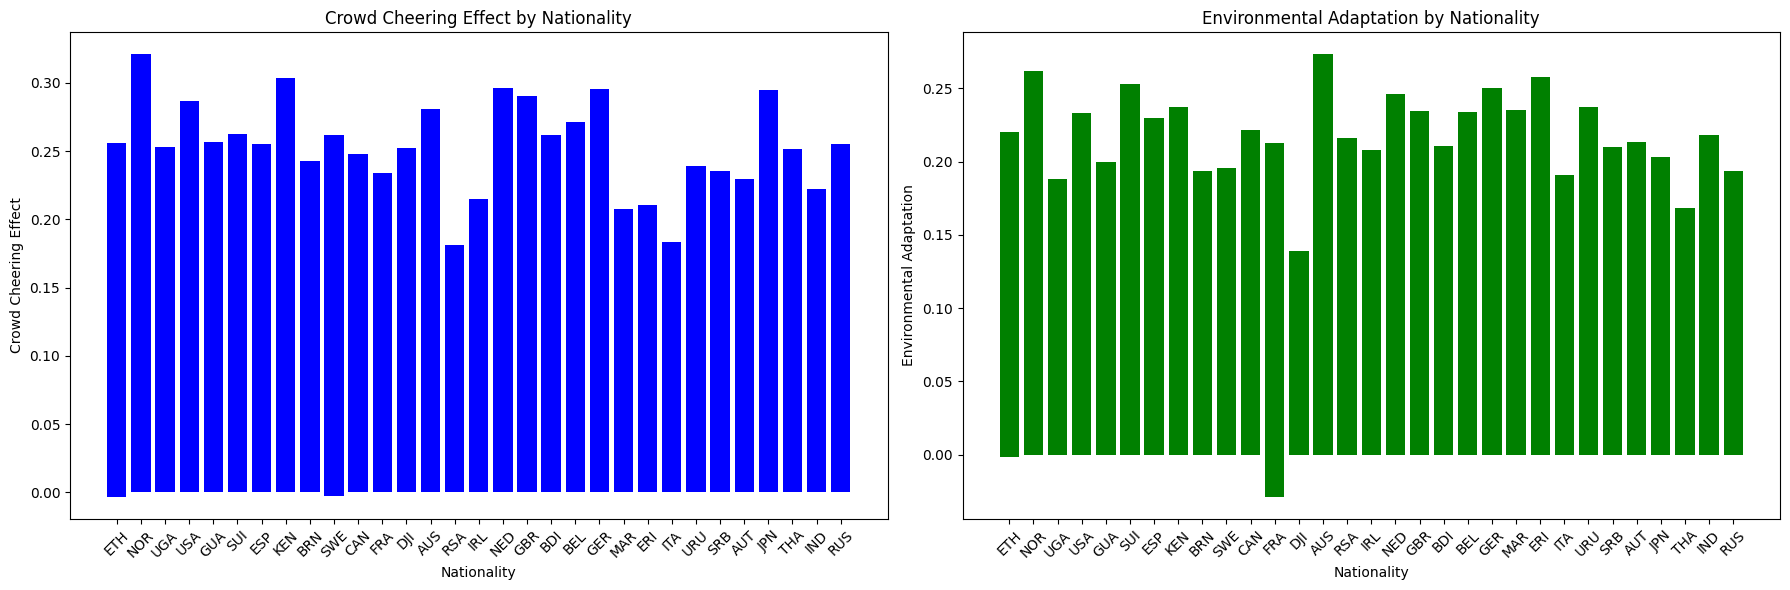

In [10]:
# Set up subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Crowd Cheering Effect by Nationality
axs[0].bar(df['Nationality'], df['CrowdCheeringEffect'], color='blue')
axs[0].set_xlabel('Nationality')
axs[0].set_ylabel('Crowd Cheering Effect')
axs[0].set_title('Crowd Cheering Effect by Nationality')
axs[0].tick_params(axis='x', rotation=45)

# Plot 2: Environmental Adaptation by Nationality
axs[1].bar(df['Nationality'], df['EnvironmentalAdaptation'], color='green')
axs[1].set_xlabel('Nationality')
axs[1].set_ylabel('Environmental Adaptation')
axs[1].set_title('Environmental Adaptation by Nationality')
axs[1].tick_params(axis='x', rotation=45)
# Adjust layout
plt.tight_layout()
plt.show()

ADD COMMENTS HERE

### Catogorical encoding

In [11]:
# Encoding Nationalities
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Nationality_encoded'] = label_encoder.fit_transform(df['Nationality'])
df['Venue_encoded'] = label_encoder.fit_transform(df['Venue'])

Also, we have extracted our data from the official athletics website. The athletes are listed through their rank. 
Let's create a column rank, the first athlete being the first best athlete in the 5000m sprint category, and the last one being the 100th one.

In [12]:
df['Rank'] = label_encoder.fit_transform(df['Athlete'])
df['Rank'] = df['Rank'].max() - df['Rank'] + 1

### Normalise / Standardise nummerical features

The goal is to predict the Score of the athletes in order to get the highest one and to predict the winner of the 5000m sprint at the olympics.

In [13]:
scaler = StandardScaler()
# Score variable
df['Score_std'] = scaler.fit_transform(df[['Score']])

In [14]:
# Creating `features`liste that is going to be our attributes for the prediction of the score 
# Features to be standardized
features = ['Nationality_encoded', 'Venue_encoded', 'Month', 'Year', 'CrowdCheeringEffect', 'EnvironmentalAdaptation']

# Apply the scaler to these features
df[features] = scaler.fit_transform(df[features])


## Data visualisation

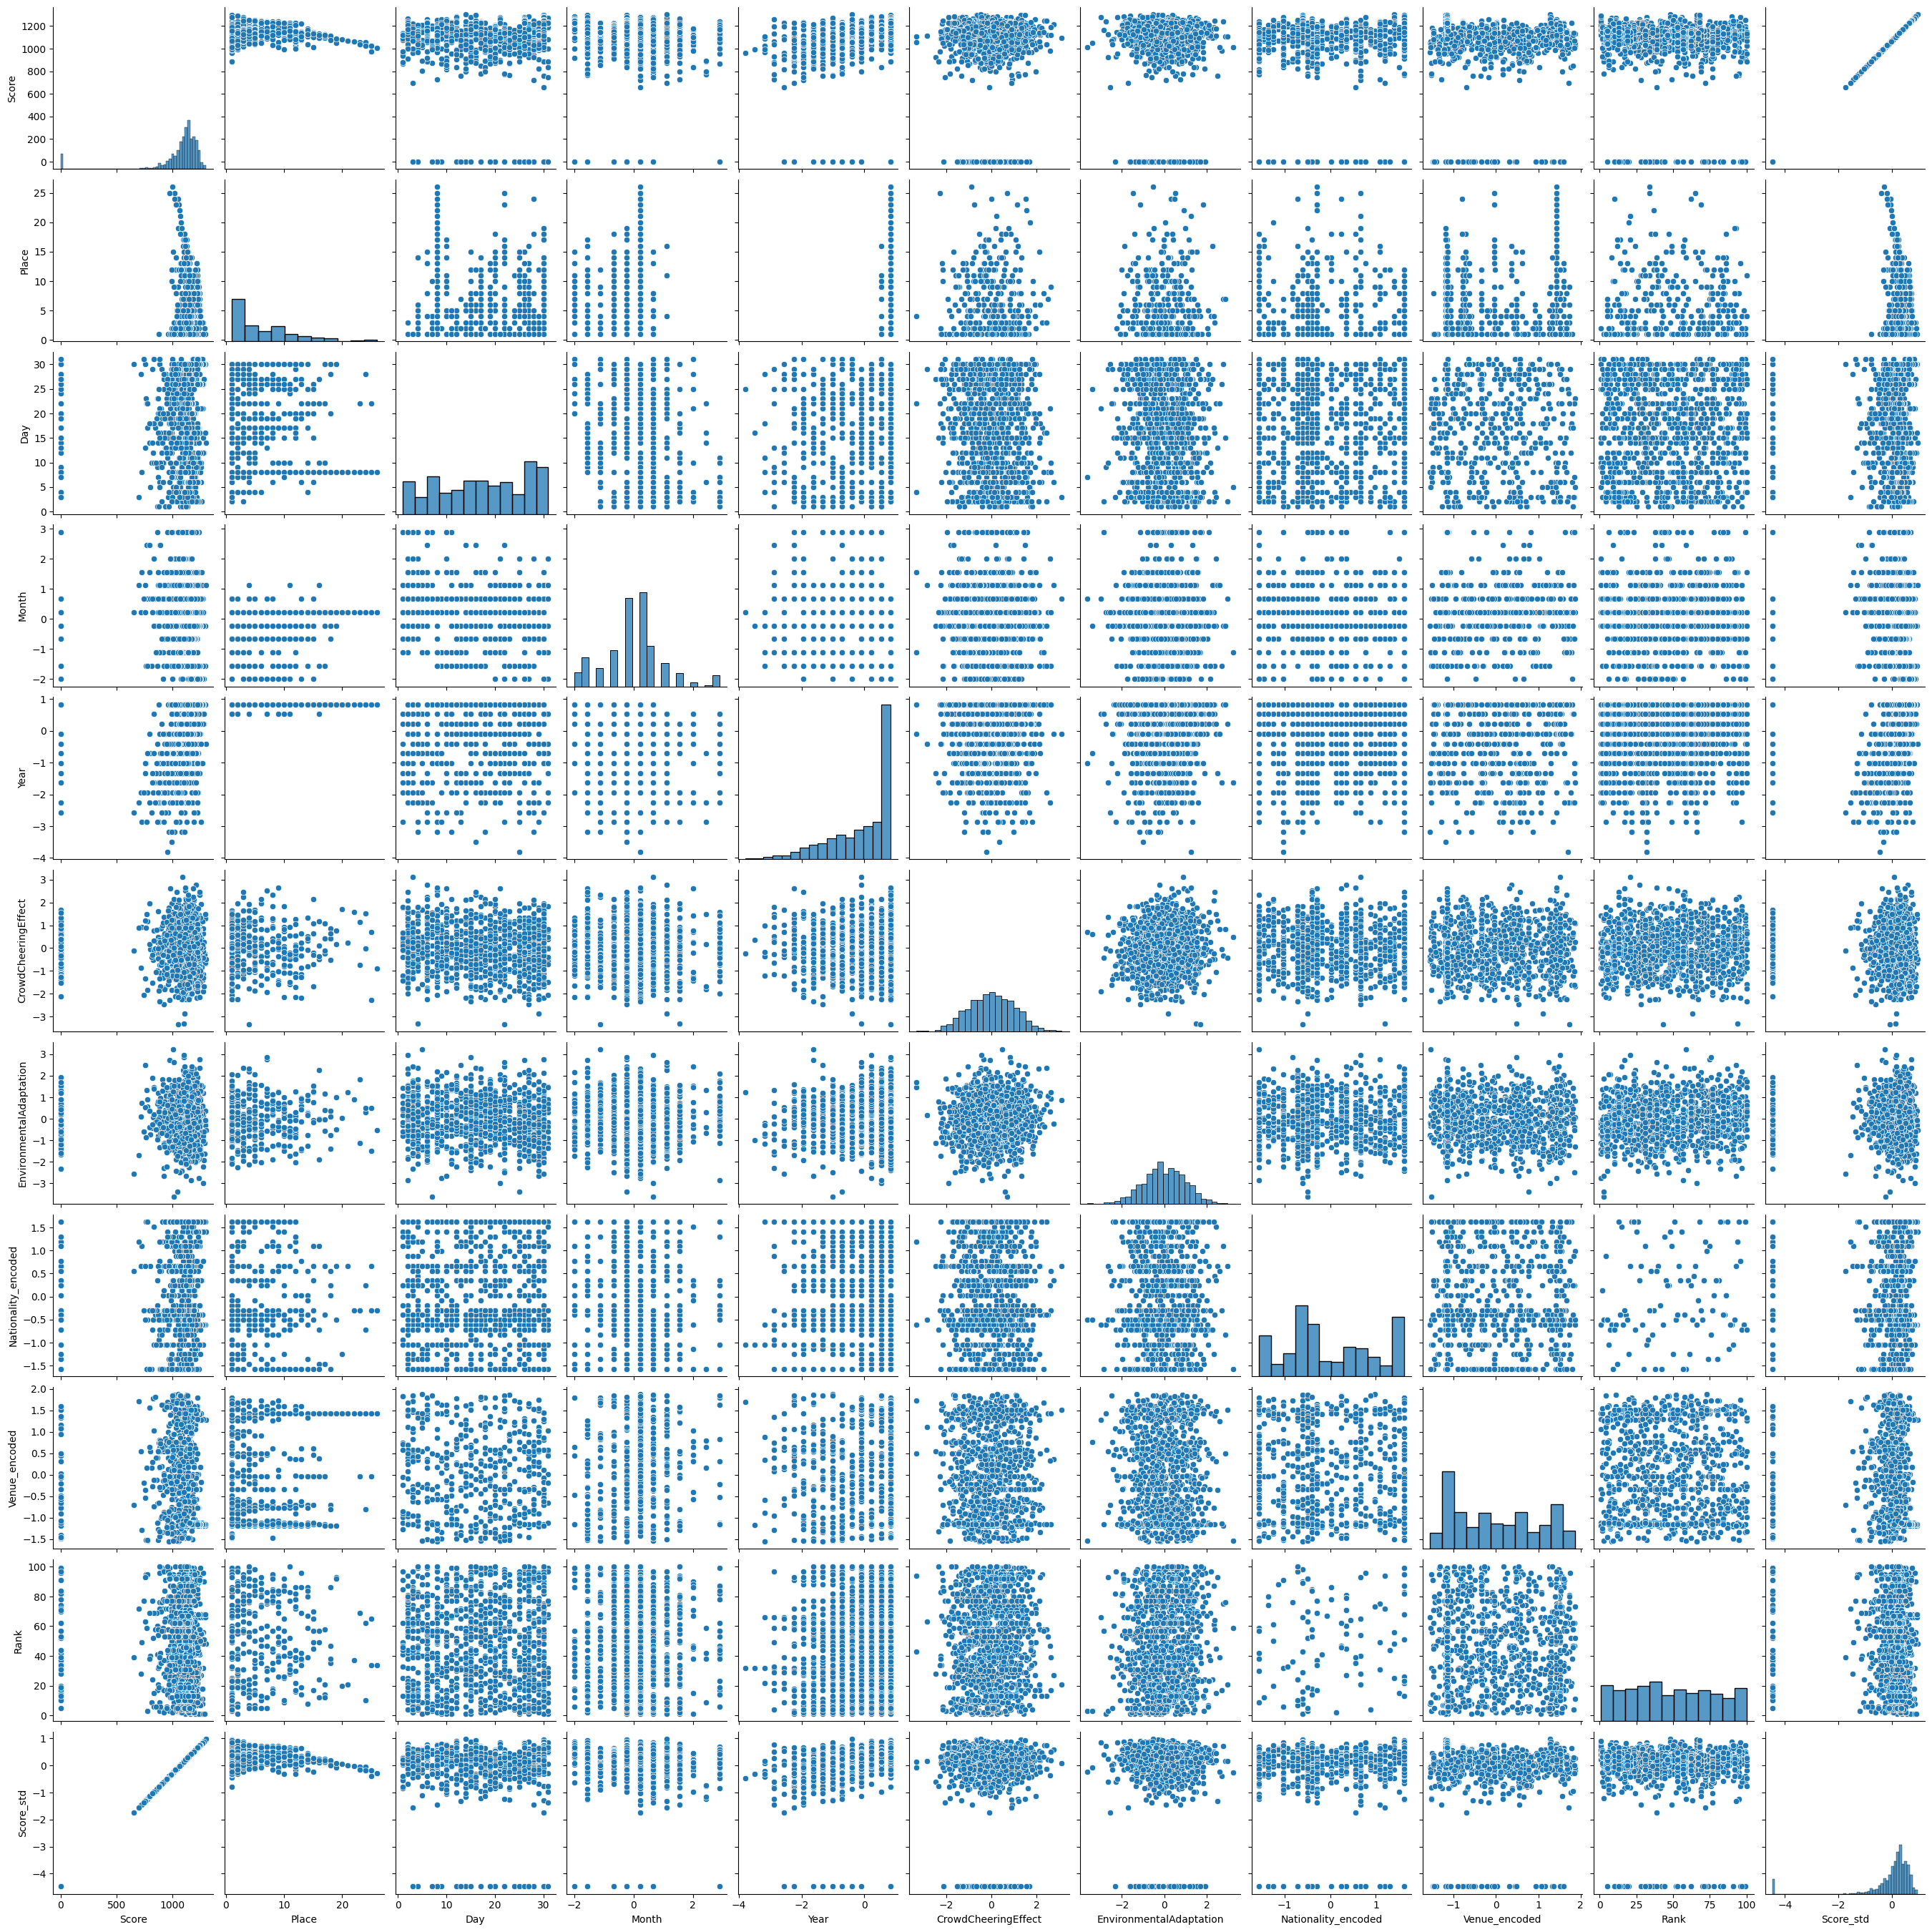

In [15]:
# Create pair plot
sns.pairplot(df)

# Show the plot
plt.show()

(array([ 45.,   0.,   0.,   0.,   0.,  11.,  41., 159., 553., 318.]),
 array([   0. ,  130.2,  260.4,  390.6,  520.8,  651. ,  781.2,  911.4,
        1041.6, 1171.8, 1302. ]),
 <BarContainer object of 10 artists>)

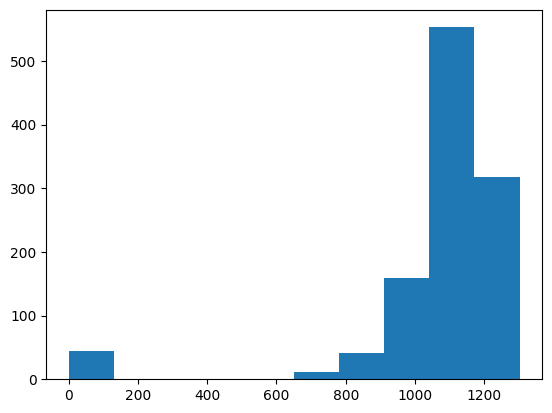

In [16]:
plt.hist(df['Score'])

We can see some outliers on the score distribution at 0, so let's remove the score equal to 0. Also, the majority of the scores are higher that 800 so let's consider only this range. This will resolve some potential outliers problems.

In [17]:
df=df[df['Score']>800]

## Label creation

We want to predict the `Score` of each individual. The one with the highest score will be considered as the winner. WE will consider the `Score_std` variable in order to neglect the weight imposed by the high Scores.

## Model

To recall, the goal of our analysis is to predict the Score of each athlete in order to predict the winner of the 5000m sprint at the olympic games in Paris the first week of August.

In order to do that we are going to tackle this problem using 3 methodologies:
- Linear regression

Because it is a regression task, the most common answer would be using Linear Regression. Let's see how it goes.

- Neural Network

We chose this first method because of several paper found on this topic such as (https://dtai.cs.kuleuven.be/events/MLSA17/papers/MLSA17_paper_4.pdf 'An Artifical Neural Netword-based Prediction Model for Underdog Teams in NBA Matches). In these papers the task was classification, so our results cannot be compared with them as ours is a regression task. 

Why use a neural network instead of a basic regression task: to get more informatiosn ADD COMMENTS HERE

- Polynomial regression? 

Because Linear regression is often not the best when used on complex datsets, we might want to use more complex regression models such as Polynomial Regression.

- Random Forest

FIND A REASON WHY, I'M TESTING EVERYTHING AT THIS POINT BECASUE I KNOW THAT THE DATASET IS NOT THE BEST, WE DON'T HAVE ENOUGH INFORMATION. THOUGH I THINK WE CAN IMPROVE IT BY PROCESSING IT A BIT BETTER ######## TO MODIFY ############

In [18]:
from sklearn.model_selection import train_test_split

# Assuming you have all features in the DataFrame and the target is winning_probability
features = ['Nationality_encoded', 'Venue_encoded', 'Month', 'Year', 'CrowdCheeringEffect', 'EnvironmentalAdaptation', 'Rank']
X = df[features]
y = df['Score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Linear Regression with Sklearn

#### With Sklearn

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Create Linear Regression Model
model_LR = LinearRegression()

In [20]:
# Train the model
model_LR.fit(X_train, y_train)

# Evaluate the model on the training data
train_r2_score = model_LR.score(X_train, y_train)
print(f"Training R-squared value: {train_r2_score}")

# Evaluate the model on the testing data
test_r2_score = model_LR.score(X_test, y_test)
print(f"Testing R-squared value: {test_r2_score}")

Training R-squared value: 0.2206225745383592
Testing R-squared value: 0.2001298027356928


The R-squared value measures how well the linear regression model fits the data, ranging from 0 to 1, where 1 indicates a perfect fit.
Here we can definitely say that the model doesn't fit the data.

In [21]:
# Predict the scores on the testing set
y_test_pred = model_LR.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error: {mse}")

# Determine the top 10 athletes based on predicted scores
test_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred}, index=X_test.index)

# Sort by predicted score in descending order and get the top 10
top_10_athletes = test_results.sort_values(by='Predicted', ascending=False).head(10)

result_LR = pd.DataFrame(
    {
        "Rank": df.loc[top_10_athletes.index, 'Rank'],
        "Top_10_athlete":  df.loc[top_10_athletes.index, 'Athlete'],
        "Actual score": top_10_athletes['Actual'],
        "Predicted score": top_10_athletes['Predicted']
    }
)
print(result_LR)


Mean Squared Error: 6943.219504654832
      Rank        Top_10_athlete  Actual score  Predicted score
26       1        Yomif KEJELCHA        1288.0      1178.335543
1995    26           Olin HACKER        1095.0      1171.185089
307     56         Jacob KIPLIMO        1236.0      1170.540013
2385    17           Sam PARSONS        1051.0      1169.372748
2239    37  Maximilian THORWIRTH        1171.0      1169.000224
200      8  Telahun Haile BEKELE        1205.0      1168.455028
3979     4      Vladimir NIKITIN        1072.0      1167.682531
3432    10        Sergio JIMÉNEZ        1161.0      1167.278390
3120    71  Emmanuel KIPCHIRCHIR        1158.0      1166.881827
3334    12        Sebastian FREY        1081.0      1166.295815


Mean Absolute Error (MAE): 63.6575464307249
Mean Squared Error (MSE): 6943.219504654832
Root Mean Squared Error (RMSE): 83.32598337046393


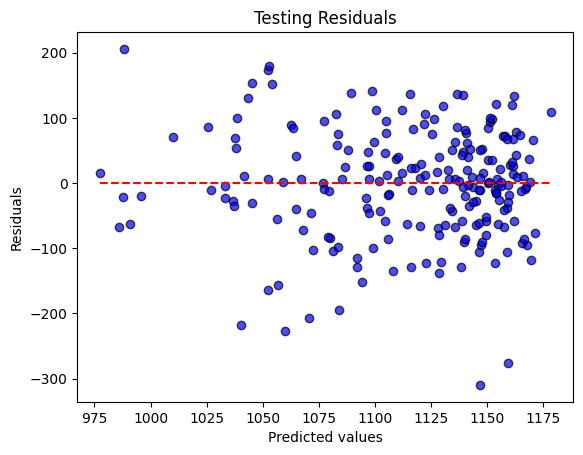

In [22]:
# Calculate residuals
test_residuals = y_test - y_test_pred
plt.scatter(y_test_pred, test_residuals, color='blue', edgecolor='k', alpha=0.7)
plt.hlines(y=0, xmin=min(y_test_pred), xmax=max(y_test_pred), colors='red', linestyles='--')
plt.title('Testing Residuals')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

# Calculate error metrics
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


In the context of predicting the scores of the finalists in the 5000m sprint at the Paris Olympic Games, this model demonstrates a useful level of performance. 

With a Mean Absolute Error (MAE) of 62.48 and a Root Mean Squared Error (RMSE) of 80.77, the average prediction error is approximately 5-6.7% of the predicted score range. This suggests that, while the model's predictions are generally close to the actual scores, there is room for improvement. For high-stakes events like Olympic finals, such an error margin can still provide valuable insights, although it may not be perfect. 

The Residuals show a rather normally distributed distribution, centered around 0. We can see a bit more around the highest values 1150 than 950, this indicates that the model tends to have a bit more difficulty predicting higher scores accurately. This could suggest a small bias or variability in predictions for higher scores.

Overall, while this model offers a solid starting point, continued refinement could increase its reliability and usefulness in making informed predictions.

#### With statsmodel
Also, in order to discover more librairies during this project, I have done this same analysis twice, with statsmodel. You can pass this section if you want. It has the same results as before.

In [24]:
import numpy as np
import statsmodels.api as sm

Mean Absolute Error (MAE): 63.814502806869086
Mean Squared Error (MSE): 6972.717063117561
Root Mean Squared Error (RMSE): 83.5027967382983


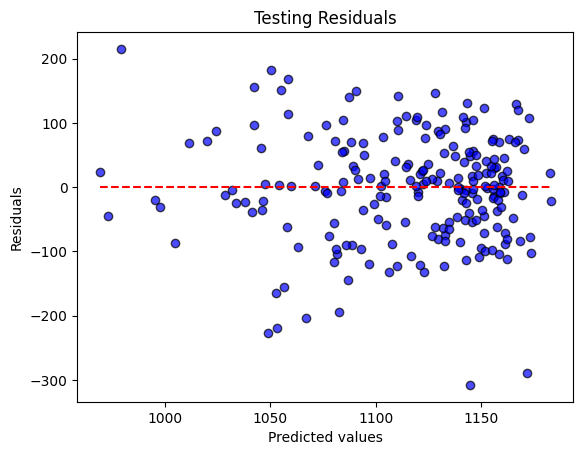

In [25]:
# Evaluate the model on the test set
X_train_const = sm.add_constant(X_train)  # Add constant term (intercept)
X_test_const = sm.add_constant(X_test)  # Add constant term (intercept)

# Fit regression model
model_LR2 = sm.OLS(y_train, X_train_const).fit()

y_test_pred2 = model_LR2.predict(X_test_const)
residuals_test2 = y_test - y_test_pred2

plt.scatter(y_test_pred2, residuals_test2, color='blue', edgecolor='k', alpha=0.7)
plt.hlines(y=0, xmin=min(y_test_pred2), xmax=max(y_test_pred2), colors='red', linestyles='--')
plt.title('Testing Residuals')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

# Calculate error metrics
mae2 = mean_absolute_error(y_test, y_test_pred2)
mse2 = mean_squared_error(y_test, y_test_pred2)
rmse2 = np.sqrt(mse2)

print(f"Mean Absolute Error (MAE): {mae2}")
print(f"Mean Squared Error (MSE): {mse2}")
print(f"Root Mean Squared Error (RMSE): {rmse2}")

### Other regression - Polynomial

In [23]:
from sklearn.preprocessing import PolynomialFeatures

# Transform the input features to include polynomial terms
degree = 2  # You can change this to any degree you want
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the model
model_PR = LinearRegression()
model_PR.fit(X_train_poly, y_train)

# Predict the scores on the testing set
y_test_pred_PR = model_PR.predict(X_test_poly)

# Calculate error metrics
mae_PR = mean_absolute_error(y_test, y_test_pred_PR)
mse_PR = mean_squared_error(y_test, y_test_pred_PR)
rmse_PR = np.sqrt(mse_PR)

print(f"Mean Absolute Error (MAE): {mae_PR}")
print(f"Mean Squared Error (MSE): {mse_PR}")
print(f"Root Mean Squared Error (RMSE): {rmse_PR}")



Mean Absolute Error (MAE): 63.676379536586296
Mean Squared Error (MSE): 6741.214091674825
Root Mean Squared Error (RMSE): 82.10489687999629


Text(0, 0.5, 'Residuals')

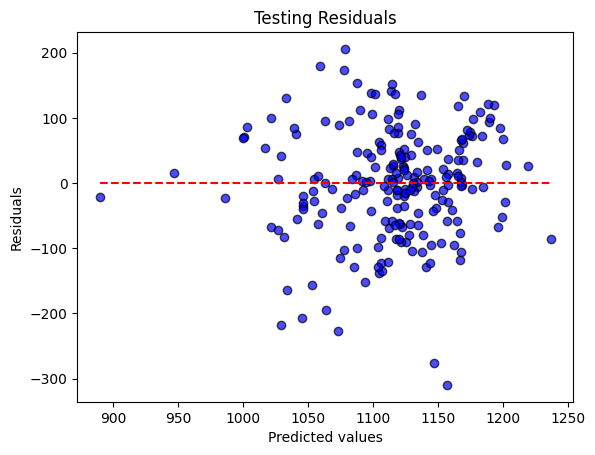

In [24]:
# Calculate residuals
test_residuals_PR = y_test - y_test_pred_PR
plt.scatter(y_test_pred_PR, test_residuals, color='blue', edgecolor='k', alpha=0.7)
plt.hlines(y=0, xmin=min(y_test_pred_PR), xmax=max(y_test_pred_PR), colors='red', linestyles='--')
plt.title('Testing Residuals')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

Given the context and the results, the model seems reliable for predicting scores above 800, approximately the same as the one before.

### Neural Network

#### With Keras

In [25]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2024-08-15 17:13:27.073187: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [26]:
# Number of features in the dataset
input_dim = X_train.shape[1]

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the model
model = Sequential()
model.add(Dense(64, input_dim=input_dim, activation='relu'))
model.add(Dropout(0.3))  # Increased dropout rate
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))  # Increased dropout rate
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))  # Output layer for regression

# Compile the model
model.compile(loss='mean_squared_error', optimizer=Adam(), metrics=['mae'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping, lr_scheduler])


Epoch 1/100
22/22 [==============================] - 1s 12ms/step - loss: 1220304.5000 - mae: 1100.6101 - val_loss: 1192093.1250 - val_mae: 1088.3799 - lr: 0.0010
Epoch 2/100
22/22 [==============================] - 0s 3ms/step - loss: 1133251.8750 - mae: 1059.3617 - val_loss: 1052252.3750 - val_mae: 1020.8561 - lr: 0.0010
Epoch 3/100
22/22 [==============================] - 0s 3ms/step - loss: 922650.1250 - mae: 948.3088 - val_loss: 738920.8125 - val_mae: 840.0457 - lr: 0.0010
Epoch 4/100
22/22 [==============================] - 0s 3ms/step - loss: 540278.2500 - mae: 670.1616 - val_loss: 377881.8125 - val_mae: 513.3727 - lr: 0.0010
Epoch 5/100
22/22 [==============================] - 0s 3ms/step - loss: 375869.2500 - mae: 520.1396 - val_loss: 331003.0938 - val_mae: 483.6569 - lr: 0.0010
Epoch 6/100
22/22 [==============================] - 0s 3ms/step - loss: 347373.4375 - mae: 493.4327 - val_loss: 334589.1562 - val_mae: 483.3152 - lr: 0.0010
Epoch 7/100
22/22 [========================

7/7 [==============================] - 0s 2ms/step - loss: 12099.9893 - mae: 88.1140
Test MAE: 88.11402130126953
34/34 [==============================] - 0s 1ms/step


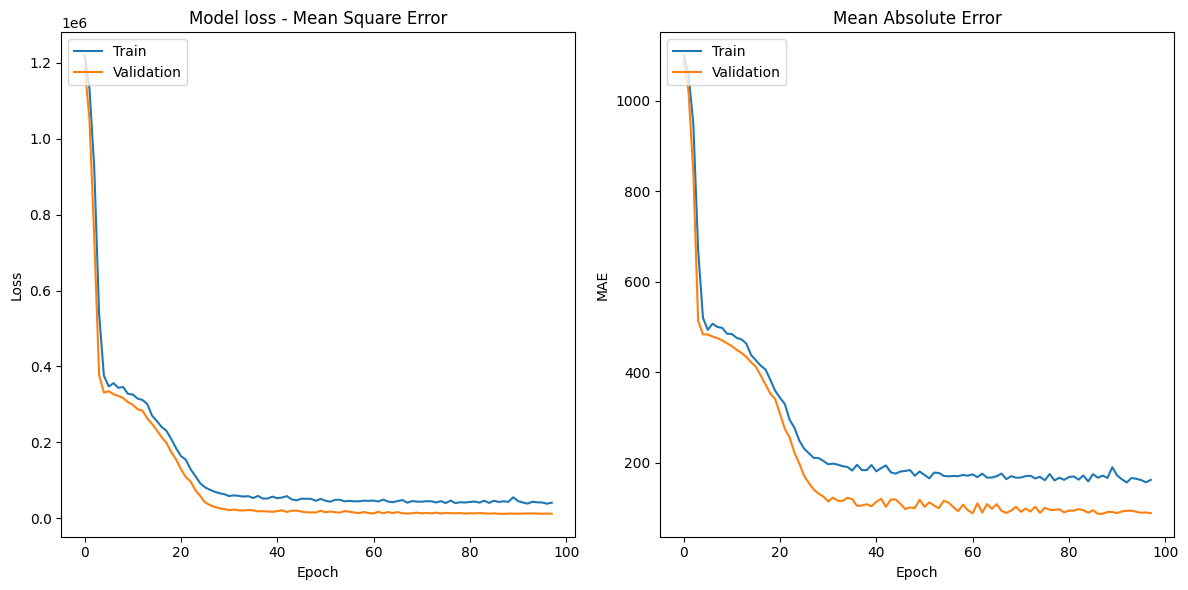

In [27]:
# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f'Test MAE: {mae}')

# Predict the scores
predictions = model.predict(X)
# Calculate R-squared
#r2 = r2_score(y, predictions)
#print(f'R-squared: {r2}')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot Mean Square Error
axs[0].plot(history.history['loss'])
axs[0].plot(history.history['val_loss'])
axs[0].set_title('Model loss - Mean Square Error')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend(['Train', 'Validation'], loc='upper left')

# Plot Mean Absolute Error
axs[1].plot(history.history['mae'])
axs[1].plot(history.history['val_mae'])
axs[1].set_title('Mean Absolute Error')
axs[1].set_ylabel('MAE')
axs[1].set_xlabel('Epoch')
axs[1].legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()  # Adjust the padding between subplots for better layout
plt.show()

In [28]:
# Predict the scores
predictions = model.predict(X)

# Print the predictions
print(predictions)

34/34 [==============================] - 0s 2ms/step
[[1162.2461]
 [1011.1856]
 [1056.0078]
 ...
 [ 978.0321]
 [1110.6345]
 [1079.2263]]


#### With PyTorch TODO!!!!!
Same as the linear regression, in order to discover more librairies during this project, I have done this same analysis twice, with pytorch instead of Kears. You can pass this section if you want. It has the same results as before.

In [32]:
# Import packages
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [33]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test,dtype=torch.float32).view(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Define DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

(855, 7)


In [34]:
# Define the neural network model
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Instantiate the model
input_dim = X_train.shape[1]
model = RegressionModel(input_dim)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


/Users/agathevianeyliaud/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# Training loop
num_epochs = 100
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)
    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}')


In [ ]:
# Evaluate the model
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    test_mae = mean_absolute_error(y_test, predictions)
    print(f'Test MAE: {test_mae}')

# Plotting training and validation loss
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot Mean Square Error
axs[0].plot(train_losses)
axs[0].plot(val_losses)
axs[0].set_title('Model loss - Mean Square Error')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend(['Train', 'Validation'], loc='upper left')

# Mean Absolute Error plot can be skipped because we did not compute it during training for simplicity

plt.tight_layout()  # Adjust the padding between subplots for better layout
plt.show()

# Predict the scores
with torch.no_grad():
    predictions = model(torch.tensor(X, dtype=torch.float32)).numpy()

# Print the predictions
print(predictions)

### Random Forest

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Perform Randomized Search with Cross-Validation
random_search = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=100, cv=5, random_state=42, n_jobs=1)
random_search.fit(X_train_scaled, y_train)

# Best model
best_rf_model = random_search.best_estimator_

/Users/agathevianeyliaud/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
140 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
140 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/agathevianeyliaud/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/agathevianeyliaud/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/Users/agathevianeyliaud/opt/anaconda3/envs/tensorfl

Mean Absolute Error (MAE_RF): 49.893107476635514
Mean Squared Error (MSE_RF): 4333.6658382009355
Root Mean Squared Error (RMSE_RF): 65.83058436776128


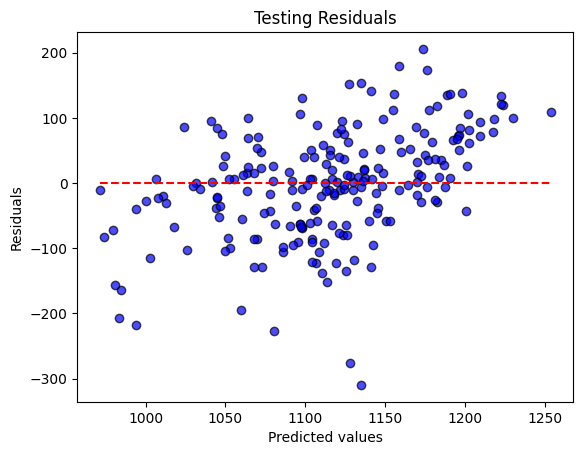

In [31]:
# Predict the scores on the testing set
y_test_pred_RF = best_rf_model.predict(X_test_scaled)

# Calculate residuals
test_residuals_RF = y_test - y_test_pred
plt.scatter(y_test_pred_RF, test_residuals_RF, color='blue', edgecolor='k', alpha=0.7)
plt.hlines(y=0, xmin=min(y_test_pred_RF), xmax=max(y_test_pred_RF), colors='red', linestyles='--')
plt.title('Testing Residuals')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

# Calculate error metrics
mae_RF = mean_absolute_error(y_test, y_test_pred_RF)
mse_RF = mean_squared_error(y_test, y_test_pred_RF)
rmse_RF = np.sqrt(mse_RF)

print(f"Mean Absolute Error (MAE_RF): {mae_RF}")
print(f"Mean Squared Error (MSE_RF): {mse_RF}")
print(f"Root Mean Squared Error (RMSE_RF): {rmse_RF}")


The key metrics indicate a Mean Absolute Error (MAE) of approximately 50.55, a Mean Squared Error (MSE) of 4373.55, and a Root Mean Squared Error (RMSE) of 66.13. These errors represent the average magnitude of the prediction errors, with lower values indicating better predictive accuracy.


The residual plot provides a visual inspection of the model's performance, plotting the residuals (the differences between the actual and predicted scores) against the predicted values. Ideally, residuals should be randomly distributed around zero, suggesting that the model does not suffer from systematic bias. 

In this plot, while most residuals cluster around zero, there is some dispersion, particularly at higher predicted values. This indicates that while the model is fairly accurate, it might have some difficulty capturing the nuances in the data, especially for higher score predictions, leading to underestimations or overestimations in some cases.

This pattern suggests that the model is reasonably well-fitted, but there is still room for improvement, possibly by refining the feature set, tuning the model parameters further, or exploring other machine learning models or ensemble approaches. Overall, this model provides a strong foundation for predicting the scores of 5000m sprint finalists, but fine-tuning could enhance its accuracy, particularly for more extreme or outlier predictions.

## Predicting the actual race winner

In [74]:
with open('data/starterlist.json', 'r') as file:
    finalists = json.load(file)

finalists_data = df[df['Athlete'].isin(finalists)].drop_duplicates(subset='Athlete')
X_finalists = finalists_data[features]
y_finalist_pred = model_LR.predict(X_finalists)


In [75]:
# Determine the top 10 athletes based on predicted scores
test_results = pd.DataFrame({'Actual': finalists_data['Athlete'], 'Predicted': y_finalist_pred})
# Sort by predicted score in descending order and get the top 10
top_10_athletes = test_results.sort_values(by='Predicted', ascending=False).head(10)

result_RF = pd.DataFrame(
    {
        "Rank": df.loc[top_10_athletes.index, 'Rank'],
        "Top_10_athlete prediction":  df.loc[top_10_athletes.index, 'Athlete'],
        "Predicted score": top_10_athletes['Predicted']
    }
)
print(result_RF)

      Rank Top_10_athlete prediction  Predicted score
600      7      Thierry NDIKUMWENAYO      1177.704688
1436     3               Yann SCHRUB      1175.286598
1930    25             Oscar CHELIMO      1170.905301
1534    18                 Sam ATKIN      1170.394147
1018    52            Jimmy GRESSIER      1169.347373
454     41             Luis GRIJALVA      1166.873669
830     94           Andreas ALMGREN      1163.851486
1164     9           Stewart MCSWEYN      1160.846263
74      66           Hagos GEBRHIWET      1158.624494
2776     6             Thomas FAFARD      1157.105365
